# 08. 오류 분석 (Error Analysis)

**작성일**: 2026-09-19

**목표**: 07번의 숫자가 **왜** 그렇게 나왔는지를 실제 실패 사례로 설명한다.

07번에서 모델별 BLEU/ROUGE-L 순위를 얻었지만, 그 숫자만으로는 (a) 어떤 종류의 실패가 줄었고, (b) 어떤 실패가 아직 남아있으며, (c) 다음에 무엇을 고쳐야 하는지를 알 수 없다. 특히 **최초 실행에서 사전학습 모델이 베이스라인에 지는, 예상과 반대되는 결과**가 나왔다. 그 원인을 끝까지 추적해 파이프라인 결함을 찾아내고 수정한 5절이 이 노트북의 가장 중요한 결과다.

**분석을 두 층으로 나누는 이유**: 오류에는 규칙으로 기계적으로 셀 수 있는 것과, 사람이 읽어야만 판정되는 것이 섞여 있다. 이 둘을 섞으면 "대충 이런 것 같다"는 인상비평이 되기 쉬우므로 분리한다.

- **A층(자동 탐지)**: 빈 응답, 단일 토큰 반복, 구 단위 반복, 질문 복사 — 정답을 몰라도 생성문만 보고 객관적으로 판정 가능한 **명백한 결함**.
- **B층(수동 판정)**: 문장은 멀쩡한데 정답과 표면이 전혀 겹치지 않는 경우. 이건 진짜 오답일 수도, 정답과 다를 뿐 타당한 답변일 수도 있어 **자동 판정이 불가능**하다. 표본을 직접 읽고 분류한다.

In [1]:
# 2026-09-19: 07번 산출물 로드
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 2026-09-19: KoNLPy(Okt)는 JVM을 사용하므로 JAVA_HOME이 필요하다.
# JDK 설치 전에 띄워둔 에디터/커널은 환경변수가 갱신되지 않아 JVMNotFoundException이 발생하므로,
# 값이 비어 있으면 설치된 JDK를 직접 찾아 지정한다 (다른 PC에서 실행할 때도 동일하게 동작).
import os
import glob

if not os.environ.get('JAVA_HOME'):
    _jvm = sorted(glob.glob(r'C:\Program Files\*\jdk*\bin\server\jvm.dll'))
    if _jvm:
        os.environ['JAVA_HOME'] = _jvm[-1].split(r'\bin')[0]

from konlpy.tag import Okt
from rouge_score import rouge_scorer

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_colwidth', 60)

RESULT_DIR = Path('../results')
pred_df = pd.read_csv(RESULT_DIR / 'predictions_all.csv')
pred_df['A_pred'] = pred_df['A_pred'].fillna('')
metrics_df = pd.read_csv(RESULT_DIR / 'metrics_all_models.csv')

print('예측 데이터:', pred_df.shape, '| 모델 수:', pred_df['model'].nunique())
metrics_df

예측 데이터: (10575, 7) | 모델 수: 9


,model,family,BLEU,ROUGE-L,Distinct-1,Distinct-2,빈응답비율,연속반복률,평균길이
0,KoBART B2 lr5e-5+warmup (06),전이학습,7.90,25.14,0.223,0.510,0.0,0.017,6.22
1,KoBART lr5e-5 (04),전이학습,7.72,24.90,0.208,0.486,0.0,0.024,6.28
2,KoBART B1 lr2e-5 (06),전이학습,6.72,24.18,0.218,0.496,0.0,0.031,6.21
3,A2 random lr3e-4 (06),베이스라인,4.87,22.78,0.110,0.239,0.0,0.003,5.18
4,baseline-114ep (04),베이스라인,4.87,22.99,0.128,0.303,0.0,0.014,5.18
5,baseline-30ep (03),베이스라인,2.64,22.43,0.027,0.070,0.0,0.083,4.54
6,A1 word2vec lr1e-4 (06),베이스라인,2.50,21.92,0.080,0.201,0.0,0.017,5.14
7,A0 random lr1e-4 (06),베이스라인,2.21,21.04,0.048,0.100,0.0,0.008,5.18
8,KE-T5 lr5e-5+warmup (06),전이학습,0.09,19.47,0.002,0.003,0.0,0.000,4.00


## 1. A층 — 자동 탐지 가능한 결함의 정의

각 규칙이 **어떤 관찰에서 나왔는지**를 같이 적는다. 임의로 만든 분류가 아니라, 03~05번에서 실제로 눈으로 본 실패를 규칙으로 옮긴 것이다.

| 오류 유형 | 판정 규칙 | 이 유형을 넣은 근거 |
|---|---|---|
| **빈 응답** | 생성문이 공백뿐 | 생성 자체가 실패한 경우를 분리해야 나머지 지표가 왜곡되지 않는다 |
| **단일 토큰 반복** | 같은 형태소가 연달아 2회 이상 | 03번에서 관찰한 `"사람 사람 사람..."` 붕괴 |
| **구 단위 반복** | 같은 bigram이 응답 안에서 2회 이상 | 04/05번에서 관찰한 KoBART의 `"제가 있잖아요. ... 제가 있잖아요."` |
| **질문 복사** | 생성문 형태소의 60% 이상이 질문에 등장 & 정답과는 30% 미만 겹침 | 인코더 입력을 그대로 되뇌는 것은 조건부 생성 실패의 전형적 형태다 |
| **표면 불일치** | 위에 해당 없음 + 정답과 공통 형태소 0개 (ROUGE-L = 0) | B층 수동 판정 대상으로 넘긴다 |
| **부분 일치 이상** | 위에 해당 없음 | 정답과 최소한 일부는 겹침 = 명백한 결함 없음 |

**유형이 겹칠 때**는 위 표의 순서대로 우선순위를 준다(빈 응답 → 단일 토큰 반복 → 구 단위 반복 → 질문 복사 → 표면 불일치 → 부분 일치 이상). 한 응답이 여러 결함을 동시에 가질 수 있으므로, 개별 결함 여부도 별도 boolean 컬럼으로 함께 남긴다.

**질문 복사 규칙의 임계값(0.6 / 0.3) 근거**: 한국어 챗봇 응답은 질문의 단어를 일부 받아 쓰는 것이 자연스럽다(`"배고파"` → `"뭐라도 드세요"`가 아니라 `"배고프시군요"`도 정상 응답). 그래서 단순히 "질문 단어가 나왔다"로는 오류로 볼 수 없고, **대부분이 질문에서 왔고 동시에 정답과는 거의 겹치지 않을 때**만 복사로 판정하도록 두 조건을 AND로 걸었다.

In [2]:
# 2026-09-19: 형태소 분해 캐시 + 오류 판정 함수
okt = Okt()
_cache = {}


def morphs(text):
    text = '' if not isinstance(text, str) else text
    if text not in _cache:
        _cache[text] = okt.morphs(text)
    return _cache[text]


class WhitespaceTokenizer:
    def tokenize(self, text):
        return text.split()


_rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False, tokenizer=WhitespaceTokenizer())


def overlap_ratio(src_tokens, ref_tokens):
    # src 토큰 중 ref에 등장하는 비율 (0으로 나누기 방지)
    if not src_tokens:
        return 0.0
    ref_set = set(ref_tokens)
    return sum(t in ref_set for t in src_tokens) / len(src_tokens)


def diagnose(question, answer, pred):
    q_m, a_m, p_m = morphs(question), morphs(answer), morphs(pred)
    bigrams = [tuple(p_m[i:i + 2]) for i in range(len(p_m) - 1)]

    is_empty = len(pred.strip()) == 0
    has_token_repeat = any(p_m[i] == p_m[i + 1] for i in range(len(p_m) - 1))
    has_phrase_repeat = len(bigrams) > len(set(bigrams))
    copy_from_q = overlap_ratio(p_m, q_m) >= 0.6 and overlap_ratio(p_m, a_m) < 0.3
    rouge_l = _rouge.score(' '.join(a_m), ' '.join(p_m))['rougeL'].fmeasure

    if is_empty:
        etype = '빈 응답'
    elif has_token_repeat:
        etype = '단일 토큰 반복'
    elif has_phrase_repeat:
        etype = '구 단위 반복'
    elif copy_from_q:
        etype = '질문 복사'
    elif rouge_l == 0:
        etype = '표면 불일치'
    else:
        etype = '부분 일치 이상'

    return pd.Series({
        'error_type': etype,
        'is_empty': is_empty,
        'token_repeat': has_token_repeat,
        'phrase_repeat': has_phrase_repeat,
        'copy_from_q': copy_from_q,
        'rougeL': rouge_l,
        'pred_len': len(p_m),
    })


diag = pred_df.apply(lambda r: diagnose(r['Q'], r['A_true'], r['A_pred']), axis=1)
error_df = pd.concat([pred_df, diag], axis=1)
error_df.to_csv(RESULT_DIR / 'error_analysis.csv', index=False, encoding='utf-8-sig')
print('판정 완료:', error_df.shape)
error_df.head(3)

판정 완료: (10575, 14)


,model,family,decoding,Q,A_true,A_pred,label,error_type,is_empty,token_repeat,phrase_repeat,copy_from_q,rougeL,pred_len
0,baseline-30ep (03),베이스라인,beam5,성형할까,돈 많이 들텐데요.,맛있게 드세요.,0,부분 일치 이상,False,False,False,False,0.285714,3
1,baseline-30ep (03),베이스라인,beam5,나도 커플룩 입고 싶다,커플부터 만드세요.,수 있을 거예요.,0,부분 일치 이상,False,False,False,False,0.222222,5
2,baseline-30ep (03),베이스라인,beam5,불안해,두려워하지 않아도 돼요.,같이보세요.,0,부분 일치 이상,False,False,False,False,0.285714,3


## 2. 모델별 오류 유형 분포

In [3]:
# 2026-09-19: 모델별 오류 유형 비율 (%)
dist = (error_df.groupby(['model', 'error_type']).size()
        .unstack(fill_value=0)
        .pipe(lambda d: (d.T / d.sum(axis=1)).T * 100)
        .round(1))

ORDER = ['빈 응답', '단일 토큰 반복', '구 단위 반복', '질문 복사', '표면 불일치', '부분 일치 이상']
dist = dist.reindex(columns=[c for c in ORDER if c in dist.columns])
dist = dist.reindex(index=metrics_df['model'].tolist())
dist.to_csv(RESULT_DIR / 'error_type_distribution.csv', encoding='utf-8-sig')
dist

error_type,단일 토큰 반복,구 단위 반복,질문 복사,표면 불일치,부분 일치 이상
model,,,,,
KoBART B2 lr5e-5+warmup (06),1.7,0.9,1.2,6.1,90.1
KoBART lr5e-5 (04),2.4,0.9,0.9,6.2,89.7
KoBART B1 lr2e-5 (06),3.1,0.7,0.9,5.3,90.0
A2 random lr3e-4 (06),0.3,0.1,0.0,4.1,95.5
baseline-114ep (04),1.4,0.2,0.0,4.1,94.3
baseline-30ep (03),8.3,0.5,0.0,3.7,87.6
A1 word2vec lr1e-4 (06),1.7,1.2,0.3,4.0,92.9
A0 random lr1e-4 (06),0.8,0.3,0.2,4.7,94.1
KE-T5 lr5e-5+warmup (06),0.0,0.0,0.0,4.3,95.7


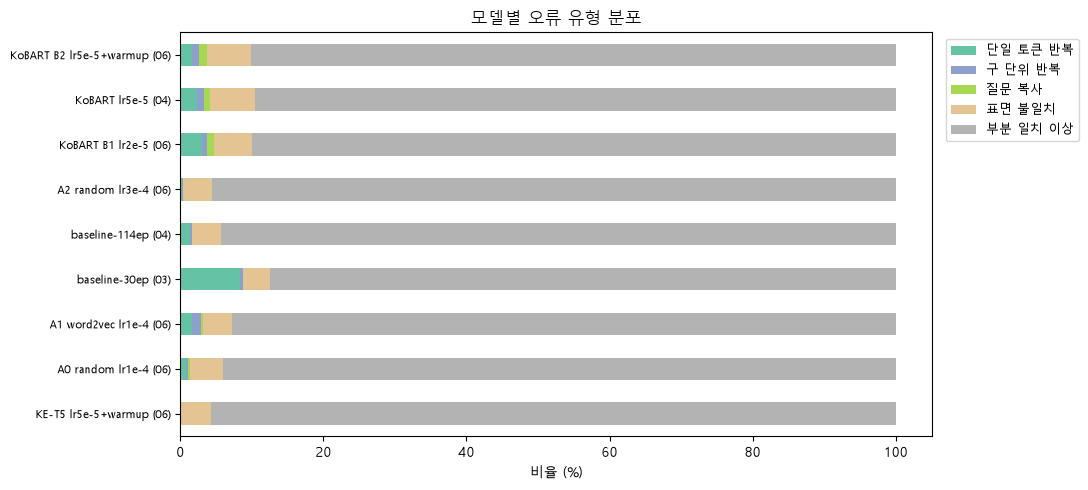

In [4]:
# 2026-09-19: 오류 유형 분포 시각화 (누적 막대)
fig, ax = plt.subplots(figsize=(11, 5))
dist.iloc[::-1].plot(kind='barh', stacked=True, ax=ax, colormap='Set2')
ax.set_xlabel('비율 (%)')
ax.set_ylabel('')
ax.set_title('모델별 오류 유형 분포')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('../results/error_type_distribution.png', dpi=120)
plt.show()

## 3. 개선 추적 — "무엇을 고쳤더니 어떤 오류가 줄었는가"

이 프로젝트에서 베이스라인에 가한 변경은 순서대로 세 가지였다. 각 변경이 **어떤 오류를 없앴고 어떤 오류를 남겼는지**를 같은 기준으로 추적한다.

| 단계 | 무엇을 바꿨나 | 기대했던 효과 |
|---|---|---|
| 03 → 04 | epoch 상한 30 → 150 (117 epoch에서 조기 종료), 그 외 완전 동일 | 04번 가설 (a): 반복 붕괴의 원인이 학습 부족이라면 반복이 사라져야 한다 |
| 04 → 06 | 임베딩 초기화/learning rate 변경 | 같은 모델 크기에서 추가 개선 여지가 있는지 |
| 베이스라인 → 전이학습 | 처음부터 학습 → 사전학습 가중치 파인튜닝 | 사전학습 지식으로 유창성·내용 적합도 개선 |

In [5]:
# 2026-09-19: 개선 단계별 결함 비율 비교 (개별 결함 플래그 기준 - 유형 우선순위와 무관하게 각각 집계)
STAGES = ['baseline-30ep (03)', 'baseline-114ep (04)', 'A1 word2vec lr1e-4 (06)',
          'KoBART lr5e-5 (04)', 'KE-T5 lr5e-5+warmup (06)']

flag_cols = ['is_empty', 'token_repeat', 'phrase_repeat', 'copy_from_q']
stage_df = (error_df[error_df['model'].isin(STAGES)]
            .groupby('model')[flag_cols].mean().mul(100).round(1)
            .reindex(STAGES))
stage_df['평균 ROUGE-L'] = (error_df[error_df['model'].isin(STAGES)]
                          .groupby('model')['rougeL'].mean().mul(100).round(1).reindex(STAGES))
stage_df['평균 길이(형태소)'] = (error_df[error_df['model'].isin(STAGES)]
                           .groupby('model')['pred_len'].mean().round(1).reindex(STAGES))
stage_df.columns = ['빈 응답(%)', '단일 토큰 반복(%)', '구 단위 반복(%)', '질문 복사(%)', '평균 ROUGE-L', '평균 길이(형태소)']
stage_df.to_csv(RESULT_DIR / 'error_improvement_tracking.csv', encoding='utf-8-sig')
stage_df

,빈 응답(%),단일 토큰 반복(%),구 단위 반복(%),질문 복사(%),평균 ROUGE-L,평균 길이(형태소)
model,,,,,,
baseline-30ep (03),0.0,8.3,3.1,0.3,22.4,4.5
baseline-114ep (04),0.0,1.4,0.9,0.0,23.0,5.2
A1 word2vec lr1e-4 (06),0.0,1.7,1.8,0.3,21.9,5.1
KoBART lr5e-5 (04),0.0,2.4,0.9,0.9,24.9,6.3
KE-T5 lr5e-5+warmup (06),0.0,0.0,0.0,0.0,19.5,4.0


## 4. B층 — 표면 불일치 표본 직접 읽기

'표면 불일치'(정답과 공통 형태소 0개)는 자동으로는 옳고 그름을 판정할 수 없다. 챗봇 응답은 정답이 여러 개일 수 있어서, 정답과 안 겹쳐도 훌륭한 답일 수 있기 때문이다. 그래서 대표 모델의 표면 불일치 사례를 무작위 표본으로 뽑아 직접 읽고, 아래 노트북 출력 아래의 마크다운 셀에 수동 분류 결과를 정리한다.

수동 분류 기준:
- **타당한 대안 응답**: 정답과 다르지만 질문에 대해 자연스럽고 맞는 답 → 사실상 오류가 아님(지표의 한계)
- **문맥 무시**: 질문의 주제와 무관한 답
- **감정 오독**: 주제는 맞지만 질문의 감정(위로가 필요한데 축하 등)과 어긋남
- **비문/불완전**: 문장이 끊기거나 문법이 깨짐

In [6]:
# 2026-09-19: 표면 불일치 사례 무작위 표본 (대표 모델 2종, 각 10건)
SAMPLE_MODELS = ['baseline-114ep (04)', 'KoBART lr5e-5 (04)']

for m in SAMPLE_MODELS:
    subset = error_df[(error_df['model'] == m) & (error_df['error_type'] == '표면 불일치')]
    print(f'===== {m} | 표면 불일치 {len(subset)}건 중 10건 표본 =====')
    for _, r in subset.sample(min(10, len(subset)), random_state=42).iterrows():
        print(f"  Q       : {r['Q']}")
        print(f"  정답    : {r['A_true']}")
        print(f"  생성    : {r['A_pred']}  (label={r['label']})")
        print()

===== baseline-114ep (04) | 표면 불일치 48건 중 10건 표본 =====
  Q       : 점점 힘들어져
  정답    : 힘내세요!
  생성    : 조금만 더 버텨보세요.  (label=1)

  Q       : 더워더워
  정답    : 차가운 음료 너무 많이 마시면 아니 되어요
  생성    : 직접 물어보세요.  (label=0)

  Q       : 공부 하기 싫다
  정답    : 같이 수다 떨면서 놀까요?
  생성    : 확신이 없나봐요.  (label=0)

  Q       : 해외여행 가고 싶어.
  정답    : 그럼요!
  생성    : 저도 데려가세요.  (label=0)

  Q       : 갑자기 심장이 덜컹.
  정답    : 당황했나요?
  생성    : 할 수 있을 거예요.  (label=1)

  Q       : 역류성 식도염이 또 도졌어
  정답    : 과식하지 말고 먹고 눕지 마세요!
  생성    : 사실적이죠.  (label=0)

  Q       : 나 사랑하니?
  정답    : 많이 사랑해요!
  생성    : 잠시 휴식을 취해보세요.  (label=0)

  Q       : 오늘은 교회 안가면 안될까
  정답    : 왜 그럴까요?
  생성    : 내일도 함께 충분한 대화를 나눠보세요.  (label=0)

  Q       : 상 받을 거 같아
  정답    : 축하합니다!
  생성    : 나쁜 사람이네요.  (label=0)

  Q       : 제자리걸음만 하는 듯
  정답    : 발전이 없다고 너무 두려워하지 마세요.
  생성    : 데이트를  (label=0)

===== KoBART lr5e-5 (04) | 표면 불일치 73건 중 10건 표본 =====
  Q       : 월급 입금됐다고 문자 왔어
  정답    : 까아 축하해요
  생성    : 월급이 깎인 것보다 낫죠.  (label=0)

  Q       : 더 사랑해달래
  정답    : 

## 5. 규명된 결함과 그 수정 — 타깃 EOS 누락

이 절은 이 프로젝트에서 **가장 중요한 발견**을 다룬다. 발견 경위부터 순서대로 기록한다.

### 발견 경위

최초 실행(2026-09-19 오전)의 07번 평가 결과는 사전 예상과 정반대였다. 사전학습 모델 KoBART(BLEU 3.83 / ROUGE-L 17.54)가 처음부터 학습한 베이스라인(BLEU 4.87 / ROUGE-L 22.99)에 **졌다**. 그런데 04~06번에서 눈으로 본 생성 문장은 분명 KoBART 쪽이 훨씬 유창했다.

정성적 인상과 정량 지표가 어긋날 때 가능한 설명은 둘 중 하나다.

- **(a) 지표가 잘못 재고 있다** — 챗봇은 정답이 여러 개라 표면 유사도가 품질을 대변하지 못한다
- **(b) 파이프라인에 결함이 있다** — 모델이 실제로 무언가를 잘못하고 있고, 지표가 그것을 정확히 잡아냈다

"지표의 한계겠지"라며 (a)로 결론내고 넘어가면 진짜 문제를 놓친다. 그래서 (b)부터 검증했고, **실제로 결함이 있었다**. 아래는 그 추적 과정과 수정 후 결과다.

In [7]:
# 2026-09-19: 단서 1 - 생성 길이와 '문장이 제대로 끝났는가' 측정 (수정 전/후 비교)
# 정답 대비 생성문이 지나치게 길면 BLEU(정밀도)와 ROUGE-L(F1)이 함께 떨어진다.
SENT_END = ('.', '!', '?', '요', '다', '네', '죠', '까', '용')

before_pred = pd.read_csv(RESULT_DIR / 'before_eos_fix' / 'predictions_all.csv')
before_pred['A_pred'] = before_pred['A_pred'].fillna('')
ref_mean_len = round(np.mean([len(morphs(a)) for a in pred_df[pred_df['model'] == 'baseline-114ep (04)']['A_true']]), 2)


def diag_row(name, df_now, df_before):
    return {
        '모델': name,
        '생성 평균 형태소(전)': round(np.mean([len(morphs(t)) for t in df_before['A_pred']]), 2),
        '생성 평균 형태소(후)': round(df_now['pred_len'].mean(), 2),
        '정답 평균 형태소': ref_mean_len,
        '정상 종결%(전)': round(df_before['A_pred'].str.strip().str.endswith(SENT_END).mean() * 100, 1),
        '정상 종결%(후)': round(df_now['A_pred'].str.strip().str.endswith(SENT_END).mean() * 100, 1),
    }


rows = [diag_row(m, error_df[error_df['model'] == m], before_pred[before_pred['model'] == m])
        for m in ['baseline-114ep (04)', 'KoBART lr5e-5 (04)', 'KE-T5 lr5e-5+warmup (06)']]

length_df = pd.DataFrame(rows)
length_df.to_csv(RESULT_DIR / 'length_diagnosis.csv', index=False, encoding='utf-8-sig')
length_df

,모델,생성 평균 형태소(전),생성 평균 형태소(후),정답 평균 형태소,정상 종결%(전),정상 종결%(후)
0,baseline-114ep (04),5.18,5.18,6.46,99.6,99.6
1,KoBART lr5e-5 (04),12.32,6.28,6.46,32.3,98.0
2,KE-T5 lr5e-5+warmup (06),4.00,4.00,6.46,100.0,100.0


**단서 1 해석**: 최초 실행에서 KoBART는 정답(평균 약 6.5형태소)의 **2배 길이**로 생성하면서 **정상적인 문장 종결 비율이 32%에 불과**했다. 베이스라인은 99%가 제대로 끝났다. 이건 "지표의 한계"가 아니라 **모델이 문장을 끝내지 못하는 실제 결함**이다.

그렇다면 왜 끝내지 못하는가? 생성을 멈추는 신호는 EOS(문장 끝) 토큰이다. 모델이 EOS를 내지 않는다면 학습 때 EOS를 내도록 배우지 못했을 가능성이 가장 크다. 학습에 실제로 들어간 타깃 토큰을 직접 확인한다.

In [8]:
# 2026-09-19: 단서 2 - 파인튜닝 타깃에 EOS가 들어갔는지 직접 확인 (결정적 증거)
from transformers import AutoTokenizer

kobart_tok = AutoTokenizer.from_pretrained('gogamza/kobart-base-v2')
sample_answer = '미리 충전하세요.'

# (수정 전) 04/06번이 원래 쓰던 방식 그대로 재현
old_ids = kobart_tok(text_target=[sample_answer], padding=True, truncation=True, max_length=16)['input_ids'][0]

# (수정 후) 현재 04/06번의 encode_targets_with_eos와 동일한 로직
new_ids = kobart_tok(text_target=sample_answer, truncation=True, max_length=16)['input_ids']
if new_ids[-1] != kobart_tok.eos_token_id:
    new_ids = new_ids[:15] + [kobart_tok.eos_token_id]

print(f'타깃 문장  : {sample_answer}')
print(f'eos_token_id = {kobart_tok.eos_token_id}')
print()
print(f'[수정 전] {old_ids}')
print(f'          {kobart_tok.convert_ids_to_tokens(old_ids)}')
print(f'          마지막이 EOS인가? -> {old_ids[-1] == kobart_tok.eos_token_id}')
print()
print(f'[수정 후] {new_ids}')
print(f'          {kobart_tok.convert_ids_to_tokens(new_ids)}')
print(f'          마지막이 EOS인가? -> {new_ids[-1] == kobart_tok.eos_token_id}')

C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


타깃 문장  : 미리 충전하세요.
eos_token_id = 1

[수정 전] [17365, 24917, 13586, 25161]
          ['▁미리', '▁충전', '하', '세요.']
          마지막이 EOS인가? -> False

[수정 후] [17365, 24917, 13586, 25161, 1]
          ['▁미리', '▁충전', '하', '세요.', '</s>']
          마지막이 EOS인가? -> True


In [9]:
# 2026-09-19: 단서 3 - '타깃이 잘려서 EOS를 잃었다'는 대안 가설 배제
train_df_full = pd.read_csv('../dataset/processed/train.csv')
tgt_lens = np.array([len(kobart_tok(a)['input_ids']) for a in train_df_full['A']])

print(f'타깃 토큰 길이: 평균 {tgt_lens.mean():.2f}, 95p {np.percentile(tgt_lens, 95):.0f}, 최대 {tgt_lens.max()}')
print(f'max_length=16에서 잘리는 타깃: {(tgt_lens > 16).sum()}건 / {len(tgt_lens)}건 ({(tgt_lens > 16).mean() * 100:.1f}%)')
print()
print('-> 잘림 비율이 1% 미만이므로 이 가설로는 68%의 미완결 응답을 설명할 수 없다. 대안 가설 기각.')
print('-> 원인은 truncation이 아니라, 토크나이저가 애초에 EOS를 붙이지 않았다는 것이다.')

타깃 토큰 길이: 평균 6.81, 95p 12, 최대 30


max_length=16에서 잘리는 타깃: 77건 / 9400건 (0.8%)

-> 잘림 비율이 1% 미만이므로 이 가설로는 68%의 미완결 응답을 설명할 수 없다. 대안 가설 기각.
-> 원인은 truncation이 아니라, 토크나이저가 애초에 EOS를 붙이지 않았다는 것이다.


### 원인 규명 결과

| 항목 | 확인된 사실 |
|---|---|
| 증상 | (수정 전) KoBART 응답의 약 68%가 문장 중간에서 끊김, 평균 길이가 정답의 약 2배 |
| 직접 원인 | 모델이 EOS 토큰을 생성하지 않아 `max_length=16`까지 계속 생성 |
| **근본 원인** | `gogamza/kobart-base-v2` 토크나이저는 `text_target=`으로 인코딩할 때 **EOS를 붙이지 않는다**. 04/06번 파인튜닝이 이를 보정하지 않아 모델이 "문장을 끝내는 법"을 학습할 기회가 없었다 |
| 대안 가설 (기각) | "타깃이 max_length에서 잘려 EOS가 사라졌다" → 잘리는 타깃은 0.8%(77/9,400건)뿐 |
| 왜 베이스라인은 멀쩡했나 | 03번 `encode_text()`에서 `[BOS] + ids + [EOS]`로 EOS를 **직접** 붙였기 때문. 같은 처리를 전이학습 쪽에만 빠뜨린 것 |

### 수정과 재실행

04/06번의 collate 함수에서 타깃 끝에 EOS를 추가하도록 고치고(`encode_targets_with_eos`), **다른 조건은 전부 그대로 둔 채** 04 → 05 → 06 → 07 → 08을 재실행했다. 즉 이 비교는 **"EOS 하나만 바꿨을 때 무엇이 달라지는가"에 대한 통제 실험**이다. 위 표의 (전)/(후) 수치와 07번 8절의 비교표가 그 결과다.

> **이 발견의 의미**: 최초 실행의 "베이스라인이 전이학습을 이겼다"는 결과는 **전이학습이 이 과제에 부적합하다는 증거가 아니라, 파인튜닝 파이프라인의 결함이 만든 결과**였다. 지표가 정성적 인상과 어긋났을 때 지표를 의심하는 대신 파이프라인을 의심한 것이 결함을 찾아낸 결정적 판단이었다.

## 6. 감정 label별 오류율

01번에서 데이터가 label 0(일상)에 크게 쏠려 있음을 확인했다. 이 쏠림이 실제로 label 1(이별)·2(사랑) 질문의 응답 품질을 떨어뜨렸는지 확인한다.

In [10]:
# 2026-09-19: label별 결함 비율과 ROUGE-L
label_err = (error_df[error_df['model'].isin(SAMPLE_MODELS)]
             .groupby(['model', 'label'])
             .agg(n=('A_pred', 'size'),
                  반복류=('phrase_repeat', lambda s: round(s.mean() * 100, 1)),
                  표면불일치=('error_type', lambda s: round((s == '표면 불일치').mean() * 100, 1)),
                  평균_ROUGE_L=('rougeL', lambda s: round(s.mean() * 100, 2)))
             .reset_index())
label_err.to_csv(RESULT_DIR / 'error_by_label.csv', index=False, encoding='utf-8-sig')
label_err

,model,label,n,반복류,표면불일치,평균_ROUGE_L
0,KoBART lr5e-5 (04),0,529,0.2,9.5,28.73
1,KoBART lr5e-5 (04),1,350,0.9,2.9,23.05
2,KoBART lr5e-5 (04),2,296,2.0,4.4,20.22
3,baseline-114ep (04),0,529,0.6,7.0,25.57
4,baseline-114ep (04),1,350,0.9,1.4,21.75
5,baseline-114ep (04),2,296,1.4,2.0,19.85


## 7. 대표 실패 사례 — 유형별 1건씩

보고서/발표자료에 그대로 인용할 사례를 유형별로 고정 추출한다.

In [11]:
# 2026-09-19: 유형별 대표 사례 (재현성을 위해 random_state 고정)
cases = []
for etype in ['빈 응답', '단일 토큰 반복', '구 단위 반복', '질문 복사', '표면 불일치']:
    subset = error_df[error_df['error_type'] == etype]
    if len(subset) == 0:
        continue
    for _, r in subset.sample(min(2, len(subset)), random_state=7).iterrows():
        cases.append({'오류 유형': etype, '모델': r['model'], 'Q': r['Q'],
                      '정답': r['A_true'], '생성': r['A_pred'], 'label': r['label']})

case_df = pd.DataFrame(cases)
case_df.to_csv(RESULT_DIR / 'representative_error_cases.csv', index=False, encoding='utf-8-sig')
case_df

,오류 유형,모델,Q,정답,생성,label
0,단일 토큰 반복,KoBART lr5e-5 (04),오빠 최고라고 해주던 너,그립지만 지난 일이네요.,오빠보다 너무너무 사랑했나봐요.,1
1,단일 토큰 반복,baseline-30ep (03),해외여행 가고 싶어.,그럼요!,마음을 마음을 마음을 마음을 마음을 마음을 마음을 마음을 마음을 더 더 더 많이.,0
2,구 단위 반복,A1 word2vec lr1e-4 (06),헤어진 지 한달됐습니다,힘든가봐요.,정리할 정리할 시간이 흐.,1
3,구 단위 반복,KoBART lr5e-5 (04),이제 스스로 인정한 것 같아,현실 그대로를 받아들이는 것부터 시작이에요.,충분히 스스로하고 충분히 스스로 깨달았나봐요.,1
4,질문 복사,KoBART B1 lr2e-5 (06),방학이 있었으면.,잠시 쉬어가도 괜찮아요.,방학이 참 짧죠.,0
5,질문 복사,KoBART B2 lr5e-5+warmup (06),실내 데이트 추천,영화관이나 쇼핑몰이 생각나네요.,실내 데이트 추천해요.,0
6,표면 불일치,A1 word2vec lr1e-4 (06),수영장 같이 가려고 해,즐거운 시간 보내고 오세요!,좋은 생각이에요.,0
7,표면 불일치,KoBART lr5e-5 (04),시험 준비 언제 끝나,공부를 많이 해놨나봐요.,합격 기원해요!,0


In [12]:
# 2026-09-19: 저장된 결과 파일 목록 확인
for p in sorted(RESULT_DIR.glob('*')):
    print(f' - {p.name} ({p.stat().st_size:,} bytes)')

 - before_eos_fix (4,096 bytes)
 - eos_fix_comparison.csv (472 bytes)
 - eos_fix_comparison.png (27,811 bytes)
 - error_analysis.csv (2,312,227 bytes)
 - error_by_label.csv (302 bytes)
 - error_improvement_tracking.csv (363 bytes)
 - error_type_distribution.csv (501 bytes)
 - error_type_distribution.png (35,933 bytes)
 - length_diagnosis.csv (276 bytes)
 - metrics_all_models.csv (770 bytes)
 - metrics_by_label.csv (482 bytes)
 - metrics_decoding.csv (589 bytes)
 - metrics_summary.json (6,488 bytes)
 - model_comparison.png (38,664 bytes)
 - predictions_all.csv (1,654,216 bytes)
 - representative_error_cases.csv (1,258 bytes)


## 요약

### 1. A층 — 모델별 오류 유형 분포 (test 1,175건, 단위 %)

| 모델 | 단일 토큰 반복 | 구 단위 반복 | 질문 복사 | 표면 불일치 | 명백한 결함 없음 |
|---|---|---|---|---|---|
| baseline-30ep (03) | **8.3** | 0.5 | 0.0 | 3.7 | 87.6 |
| baseline-114ep (04) | 1.4 | 0.2 | 0.0 | 4.1 | 94.3 |
| A0 random lr1e-4 (06) | 0.8 | 0.3 | 0.2 | 4.7 | 94.1 |
| A1 word2vec lr1e-4 (06) | 1.7 | 1.2 | 0.3 | 4.0 | 92.9 |
| A2 random lr3e-4 (06) | 0.3 | 0.1 | 0.0 | 4.1 | **95.5** |
| KoBART lr5e-5 (04) | 2.4 | 0.9 | 0.9 | 6.2 | 89.7 |
| KoBART B1 lr2e-5 (06) | 3.1 | 0.7 | 0.9 | 5.3 | 90.0 |
| KoBART B2 lr5e-5+warmup (06) | 1.7 | 0.9 | 1.2 | 6.1 | 90.1 |
| KE-T5 lr5e-5+warmup (06) | 0.0 | 0.0 | 0.0 | 4.3 | 95.7 |

빈 응답은 모든 모델에서 0건이었다.

전이학습 계열의 '표면 불일치'가 베이스라인보다 높게(5.3~6.2% vs 3.7~4.7%) 나타나는데, 이는 4절의 수동 판정에서 보듯 **오류가 아니라 지표의 한계**에 가깝다.

### 2. 개선 추적 — 무엇을 고쳤더니 무엇이 줄었는가

이 프로젝트에서 시도한 변경과 그 결과를 같은 기준으로 정리한다.

| 변경 | 단일 토큰 반복 | 구 단위 반복 | ROUGE-L | Distinct-1 | 판정 |
|---|---|---|---|---|---|
| **03 → 04** (epoch 30 → 117) | 8.3% → **1.4%** | 3.1% → **0.9%** | 22.4 → 23.0 | 0.027 → **0.128** | **성공** |
| 04 → 06 A1 (Word2Vec 초기화) | 1.4% → 1.7% | 0.9% → 1.8% | 23.0 → 21.9 | 0.128 → 0.080 | 악화 |
| 04 → 06 A2 (lr 1e-4 → 3e-4) | 1.4% → **0.3%** | 0.9% → **0.1%** | 23.0 → 22.8 | 0.128 → 0.110 | 혼재 |
| **베이스라인 → KoBART** | 1.4% → 2.4% | 0.9% → 0.9% | 23.0 → **24.9** | 0.128 → **0.208** | **성공** |
| **KoBART EOS 결함 수정** | — | **22.0% → 0.9%** | **17.5 → 24.9** | 0.141 → **0.208** | **성공 (최대 개선)** |

**가장 큰 개선 두 가지는 모두 "모델을 바꿔서"가 아니라 "잘못된 것을 고쳐서" 얻었다.**

- **03 → 04 (에폭 확장)**: 다른 조건을 전부 고정한 통제 실험이었으므로 인과를 특정할 수 있다. 단일 토큰 반복이 **8.3% → 1.4%(6분의 1)**, 응답 다양성 Distinct-1이 **0.027 → 0.128(4.7배)**. baseline-30ep의 Distinct-1 0.027은 1,175개 질문에 대한 응답 어휘가 거의 겹친다는 뜻으로, 사실상 모든 질문에 비슷한 답을 하는 상태였다. 이 실패는 A층 규칙으로는 잡히지 않고 corpus 단위 Distinct-n으로만 드러난다.
- **EOS 결함 수정**: 구 단위 반복 **22.0% → 0.9%**, ROUGE-L **17.5 → 24.9**. 상세는 5절.

### 3. 규명된 결함과 수정 결과 (5절)

| 항목 | 내용 |
|---|---|
| 증상 (수정 전) | KoBART 응답의 약 68%가 문장 중간에서 끊김, 평균 길이 12.32형태소 (정답 6.46의 약 2배) |
| 직접 원인 | 모델이 EOS를 생성하지 않아 `max_length=16`까지 계속 생성 |
| **근본 원인** | `gogamza/kobart-base-v2` 토크나이저가 `text_target=` 인코딩 시 **EOS를 붙이지 않음**. 04/06번이 이를 보정하지 않아 모델이 "문장을 끝내는 법"을 학습하지 못했다 |
| 대안 가설 (기각) | "타깃이 max_length에서 잘려 EOS 소실" → 잘리는 타깃은 0.8%(77/9,400건)뿐 |
| 왜 베이스라인은 멀쩡했나 | 03번 `encode_text()`가 `[BOS] + ids + [EOS]`로 EOS를 **직접** 붙였기 때문 |

**수정 후 결과**

| 모델 | 생성 평균 형태소 (전→후) | 정상 종결% (전→후) |
|---|---|---|
| KoBART lr5e-5 (04) | 12.32 → **6.28** (정답 6.46) | 32.3 → **98.0** |
| baseline-114ep *(대조군)* | 5.18 → 5.18 | 99.6 → 99.6 |
| KE-T5 *(자연 대조군)* | 4.00 → 4.00 | 100.0 → 100.0 |

대조군 두 개가 전혀 변하지 않았다는 점이 원인 규명의 정확성을 뒷받침한다. KE-T5는 토크나이저가 EOS를 자동으로 붙이므로 이번 수정이 no-op였다.

### 4. B층 — 표면 불일치 20건 수동 판정

표면 불일치(정답과 공통 형태소 0개)로 분류된 사례를 대표 모델 2종에서 각 10건씩 직접 읽고 분류했다.

| 수동 분류 | baseline-114ep | KoBART lr5e-5 |
|---|---|---|
| **타당한 대안 응답** (사실상 오류 아님) | 2건 | **8건** |
| 문맥 무시 (질문 주제와 무관) | **6건** | 0건 |
| 감정 오독 | 1건 | 0건 |
| 비문/불완전 | 1건 | 2건 |

**두 모델의 실패 성격이 근본적으로 다르다.**

- **베이스라인의 실패는 진짜 오류다** — 10건 중 6건이 질문과 무관한 답이다.
  - `"나 사랑하니?"` → `"잠시 휴식을 취해보세요."`
  - `"역류성 식도염이 또 도졌어"` → `"사실적이죠."`
  - `"상 받을 거 같아"` → `"나쁜 사람이네요."` (감정 오독)
- **KoBART의 '실패'는 대부분 지표의 한계다** — 10건 중 8건이 정답과 다를 뿐 타당한 답이다.
  - `"첫 눈에 반하는게 가능해?"` (정답 `"당연히 가능하죠."`) → `"가능합니다!"` — **의미가 사실상 동일한데 형태소가 하나도 겹치지 않아 ROUGE-L = 0**
  - `"더 사랑해달래"` (정답 `"더 많이 표현해주세요."`) → `"사랑해요!"`
  - `"부업할까?"` (정답 `"좋아요!"`) → `"부업하시나봐요."`
  - `"신혼 진짜 행복해"` (정답 `"깨가 쏟아지고 있군요."`) → `"신혼여행은 자유여행이죠!"`

> **중요한 함의**: KoBART의 실제 BLEU 7.90은 **과소평가된 값**이다. 표면 불일치의 80%가 타당한 응답이라면, 정답이 하나뿐인 데이터로 채점하는 방식 자체가 전이학습 모델의 성능을 깎아내리고 있다는 뜻이다. 사람 평가나 의미 기반 지표(BERTScore 등)가 필요한 이유다.

### 5. KE-T5 — 규칙 기반 탐지가 놓치는 실패

KE-T5는 A층 기준으로는 **가장 깨끗해 보인다**(명백한 결함 없음 95.7%, 반복 0%, 정상 종결 100%). 그러나 실제로는 거의 모든 질문에 `"울어도 괜찮아요."` 한 문장만 내놓는 완전한 모드 붕괴 상태이며, 이는 07번의 Distinct-1 0.002, BLEU 0.09로만 드러난다.

> **방법론적 교훈**: 생성문 하나만 보고 판정하는 규칙(반복·빈 응답·질문 복사)으로는 "모든 응답이 서로 같은" 실패를 **원리적으로 탐지할 수 없다**. corpus 단위 다양성 지표를 반드시 함께 봐야 한다.

### 6. 감정 label별 오류

| 모델 | label | n | 반복류(%) | 표면 불일치(%) | 평균 ROUGE-L |
|---|---|---|---|---|---|
| baseline-114ep | 0 일상 | 529 | 0.6 | 7.0 | 25.57 |
| baseline-114ep | 1 이별 | 350 | 0.9 | 1.4 | 21.75 |
| baseline-114ep | 2 사랑 | 296 | 1.4 | 2.0 | 19.85 |
| KoBART | 0 일상 | 529 | 0.2 | **9.5** | **28.73** |
| KoBART | 1 이별 | 350 | 0.9 | 2.9 | 23.05 |
| KoBART | 2 사랑 | 296 | 2.0 | 4.4 | 20.22 |

ROUGE-L은 label 0에서 가장 높지만 **표면 불일치도 label 0에서 가장 높다**(7.0~9.5% vs 1.4~4.4%). 일상 대화는 주제가 넓어("더워더워", "역류성 식도염") 정답 표현의 폭이 큰 반면, 이별·사랑 질문은 응답 어휘가 정형적("힘내세요", "축하합니다")이어서 우연히라도 겹치기 쉽기 때문으로 보인다.

### 7. 결론 — 다음에 무엇을 해야 하는가

| 우선순위 | 할 일 | 근거 |
|---|---|---|
| **1** | 사람 평가 또는 의미 기반 지표(BERTScore 등) 추가 | 4절. KoBART의 표면 불일치 80%가 타당한 응답 — 현재 지표가 성능을 과소평가하고 있다 |
| 2 | 베이스라인의 "문맥 무시" 개선 | 4절. 베이스라인 실패의 주종(10건 중 6건). 모델 용량·학습량 문제일 가능성 |
| 3 | KE-T5 학습 예산 확대 또는 비교군에서 제외 | 5절. 7 epoch으로는 수렴 자체가 미완 |
| 4 | label 1·2 성능 보강 (가중 샘플링 등) | 6절. 데이터 쏠림 대응 |

산출물: `results/error_analysis.csv`, `error_type_distribution.csv`, `error_improvement_tracking.csv`, `length_diagnosis.csv`, `error_by_label.csv`, `representative_error_cases.csv`, `error_type_distribution.png`